# Practical 8 — Exploratory Data Analysis and Visualisation

## Objective

Explore the verified log summaries visually to understand temporal behaviour, client concentration, weak-label uncertainty, conflicts, burst regimes, and distribution drift.

**Simple meaning:** Practical 7 organised the data into trustworthy summaries. Practical 8 uses graphs and statistics to discover what those summaries reveal.

## Main analytical questions

1. How does event volume change over time?
2. Are a small number of hours or clients responsible for most activity?
3. How do train, validation, and test periods differ?
4. Do event-weighted and client-weighted conclusions disagree?
5. Where are weak labels uncertain or conflicting?
6. How do ordinary, burst, and post-burst periods differ?

## Interpretation rules

- Weak labels are evidence-based approximations, not ground truth.
- Correlation does not prove causation.
- Burst volume does not automatically mean an attack.
- Validation and test data may be described, but they must not change training decisions.
- Raw IP addresses and private pseudonym secrets must never appear in plots.
- Every percentage must clearly state its denominator.
- Logarithmic scales must be labelled because they change visual spacing, not the underlying values.

The outputs of this practical are descriptive findings and reproducible figures, not classifier-performance results.

## 1. Reproducible visualisation environment

Visual conclusions can change because of code, data, or library-version differences. Therefore, the project records its direct package versions and uses a consistent plotting configuration.

We use a colour-blind-friendly palette and save figures at publication-quality resolution.

In [2]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (
            (candidate / "data").exists()
            and (candidate / "src").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root containing data/ and src/ was not found."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

AGGREGATED_DIRECTORY = (
    PROJECT_ROOT / "data" / "aggregated"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT / "reports" / "figures" / "practical_08"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="colorblind",
)

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIRECTORY)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

Project root: c:\Users\diyas\Desktop\PDS-Log-IDS-Project
Figure directory: c:\Users\diyas\Desktop\PDS-Log-IDS-Project\reports\figures\practical_08
pandas: 3.0.5
NumPy: 2.5.2
Matplotlib: 3.11.2
Seaborn: 0.13.2


## 2. Verified EDA input contract

EDA must not silently analyse stale or modified files. Before loading the summaries, we compare every file against its recorded SHA-256 fingerprint.

This creates a **provenance gate**: visual analysis begins only after the complete input chain passes verification.

The aggregate files are small enough to load into memory because Practical 7 already reduced the original 2,062,361 events into controlled summary tables.

In [3]:
from src.aggregation import calculate_file_sha256

AGGREGATION_MANIFEST_FILE = (
    AGGREGATED_DIRECTORY / "cj_aggregation_manifest.json"
)

REGIME_MANIFEST_FILE = (
    AGGREGATED_DIRECTORY
    / "cj_hourly_regimes_manifest.json"
)

with AGGREGATION_MANIFEST_FILE.open(
    encoding="utf-8"
) as file:
    aggregation_manifest = json.load(file)

with REGIME_MANIFEST_FILE.open(
    encoding="utf-8"
) as file:
    regime_manifest = json.load(file)

artifact_paths = {
    view_name: PROJECT_ROOT / metadata["file"]
    for view_name, metadata
    in aggregation_manifest["outputs"].items()
}

artifact_paths["hourly_regimes"] = (
    PROJECT_ROOT / regime_manifest["output_file"]
)

for view_name, metadata in (
    aggregation_manifest["outputs"].items()
):
    actual_sha256 = calculate_file_sha256(
        artifact_paths[view_name]
    )

    assert actual_sha256 == metadata["sha256"]

assert (
    calculate_file_sha256(
        artifact_paths["hourly_regimes"]
    )
    == regime_manifest["output_sha256"]
)

assert (
    calculate_file_sha256(
        AGGREGATION_MANIFEST_FILE
    )
    == regime_manifest[
        "source_aggregation_manifest_sha256"
    ]
)

assert (
    regime_manifest["source_sha256"]
    == aggregation_manifest["outputs"][
        "hourly_summary"
    ]["sha256"]
)

print("Base aggregate fingerprints: passed")
print("Regime fingerprint: passed")
print("Manifest chain: passed")

Base aggregate fingerprints: passed
Regime fingerprint: passed
Manifest chain: passed


In [4]:
hourly = pd.read_csv(
    artifact_paths["hourly_summary"],
    parse_dates=["hour_start"],
)

daily = pd.read_csv(
    artifact_paths["daily_summary"],
    parse_dates=["day"],
)

client_split = pd.read_csv(
    artifact_paths["client_split_summary"],
    parse_dates=[
        "first_timestamp",
        "last_timestamp",
    ],
)

client_daily = pd.read_csv(
    artifact_paths["client_daily_summary"],
    parse_dates=[
        "day",
        "first_timestamp",
        "last_timestamp",
    ],
)

hourly_regimes = pd.read_csv(
    artifact_paths["hourly_regimes"],
    parse_dates=["hour_start"],
)

EXPECTED_ROWS = aggregation_manifest["input_rows"]

loaded_views = {
    "hourly": hourly,
    "daily": daily,
    "client_split": client_split,
    "client_daily": client_daily,
    "hourly_regimes": hourly_regimes,
}

for view_name, frame in loaded_views.items():
    assert int(frame["event_count"].sum()) == EXPECTED_ROWS

print(
    "Aggregation version:",
    aggregation_manifest["aggregation_version"],
)
print(
    "Regime version:",
    regime_manifest["regime_version"],
)
print(f"Represented events per view: {EXPECTED_ROWS:,}")
print(
    "Observed period:",
    aggregation_manifest["minimum_timestamp"],
    "to",
    aggregation_manifest["maximum_timestamp"],
)

pd.DataFrame({
    "view": loaded_views.keys(),
    "rows": [
        len(frame)
        for frame in loaded_views.values()
    ],
})

Aggregation version: aggregation-v1
Regime version: active-hour-quantile-v1
Represented events per view: 2,062,361
Observed period: 2023-01-08T08:07:15 to 2024-02-19T21:44:01


,view,rows
0,hourly,9778
1,daily,408
2,client_split,17607
3,client_daily,32809
4,hourly_regimes,9778


## 3. Temporal event-volume profile

Before choosing a chart scale, we measure the distribution of daily event counts.

A linear scale preserves absolute differences, but a few extreme days can flatten ordinary activity until it becomes invisible. A logarithmic scale allows both small and extremely large values to remain visible.

The scale must be chosen from the measured dynamic range, not for visual appearance.

### Denominators

- `day_count` counts calendar days within each split.
- `event_share_percent` divides by all 2,062,361 events.
- Per-day statistics treat every day equally.

In [8]:
SPLIT_ORDER = ["train", "validation", "test"]

daily_volume_summary = (
    daily
    .groupby(
        "data_split",
        observed=True,
    )
    .agg(
        day_count=("day", "size"),
        total_events=("event_count", "sum"),
        mean_events_per_day=("event_count", "mean"),
        median_events_per_day=("event_count", "median"),
        p95_events_per_day=(
            "event_count",
            lambda values: values.quantile(0.95),
        ),
        maximum_events_per_day=("event_count", "max"),
        median_unique_clients=(
            "unique_client_count",
            "median",
        ),
    )
    .reindex(SPLIT_ORDER)
    .reset_index()
)

daily_volume_summary["event_share_percent"] = (
    100.0
    * daily_volume_summary["total_events"]
    / EXPECTED_ROWS
)

daily_volume_summary["maximum_to_median_ratio"] = (
    daily_volume_summary["maximum_events_per_day"]
    / daily_volume_summary["median_events_per_day"]
)

expected_days = pd.date_range(
    daily["day"].min(),
    daily["day"].max(),
    freq="D",
)

missing_days = expected_days.difference(
    pd.DatetimeIndex(daily["day"])
)

positive_daily_counts = daily.loc[
    daily["event_count"] > 0,
    "event_count",
]

overall_dynamic_range = (
    positive_daily_counts.max()
    / positive_daily_counts.min()
)

assert len(missing_days) == 0
assert int(daily_volume_summary["total_events"].sum()) == EXPECTED_ROWS

print(f"Calendar days represented: {len(daily):,}")
print("Missing calendar days:", len(missing_days))
print(
    "Largest-to-smallest daily volume ratio:",
    f"{overall_dynamic_range:,.2f}:1",
)
print(
    "Logarithmic scale justified:",
    overall_dynamic_range >= 100,
)

daily_volume_summary.round(3)

Calendar days represented: 408
Missing calendar days: 0
Largest-to-smallest daily volume ratio: 6,372.34:1
Logarithmic scale justified: True


,data_split,day_count,total_events,mean_events_per_day,median_events_per_day,p95_events_per_day,maximum_events_per_day,median_unique_clients,event_share_percent,maximum_to_median_ratio
0,train,358,266252,743.721,272.0,1014.05,63643,82.0,12.910,233.982
1,validation,31,480477,15499.258,215.0,51076.50,351804,61.0,23.297,1636.298
2,test,19,1315632,69243.789,322.0,625374.10,688213,61.0,63.793,2137.307


Figure creation: passed
Saved: c:\Users\diyas\Desktop\PDS-Log-IDS-Project\reports\figures\practical_08\01_daily_event_volume.png


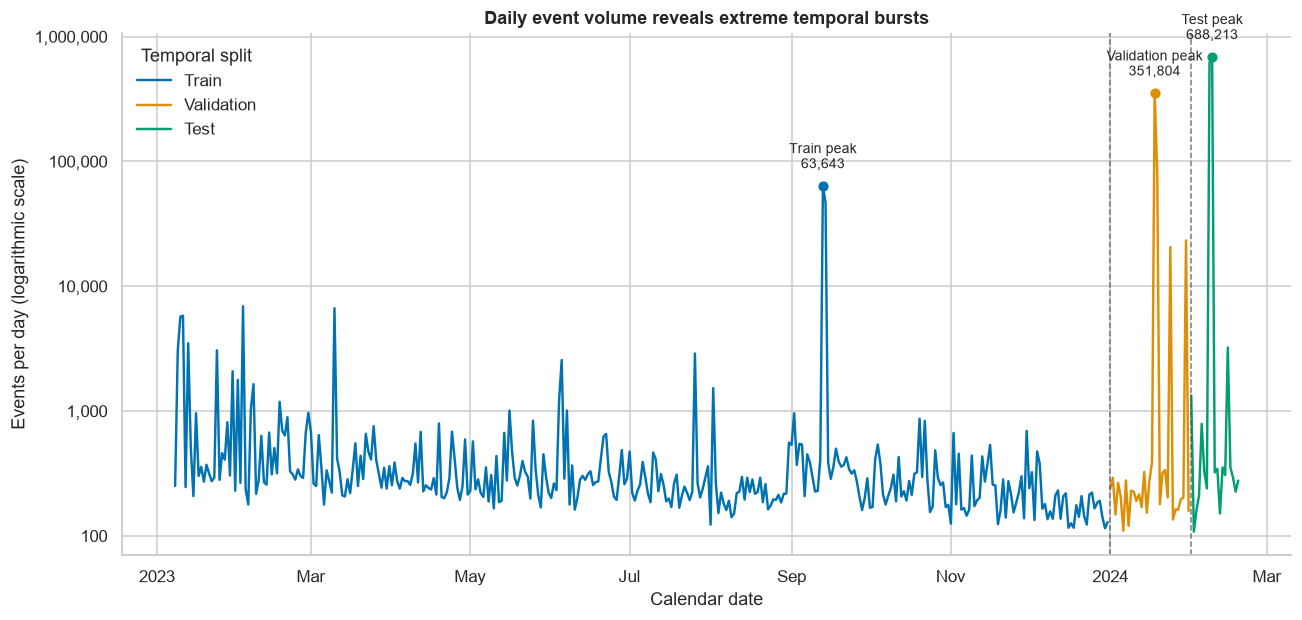

In [10]:
import src.visualization as visualization

importlib.reload(visualization)

daily_volume_figure, daily_volume_axis = (
    visualization.plot_daily_event_volume(
        daily_summary=daily,
        output_path=(
            FIGURE_DIRECTORY
            / "01_daily_event_volume.png"
        ),
    )
)

figure_path = (
    FIGURE_DIRECTORY / "01_daily_event_volume.png"
)

assert figure_path.exists()
assert figure_path.stat().st_size > 0

print("Figure creation: passed")
print("Saved:", figure_path)

plt.show()

### Finding 1 — Temporal volume is non-stationary

Daily traffic does not increase smoothly. Most days remain within a similar range, while a small number of isolated days create enormous peaks.

The largest observed daily volumes are:

- Training: 63,643 events
- Validation: 351,804 events
- Test: 688,213 events

Therefore, later evaluation periods are not merely larger versions of training. They contain substantially more concentrated bursts, making temporal evaluation harder and more realistic than a random split.